In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## 直方图

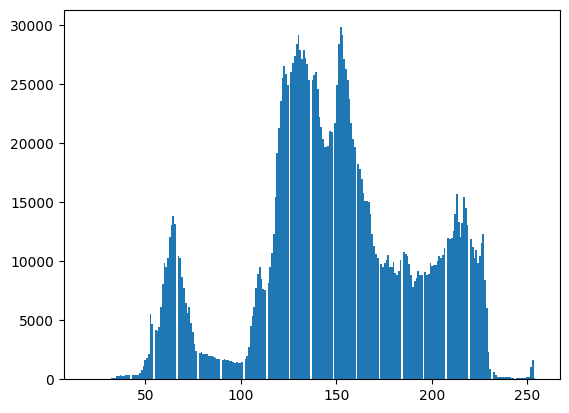

In [ ]:
img = cv2.imread('./assets/1.jpg', 0) # 0 表示灰度图
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.hist(img.ravel(), 256)
plt.show()


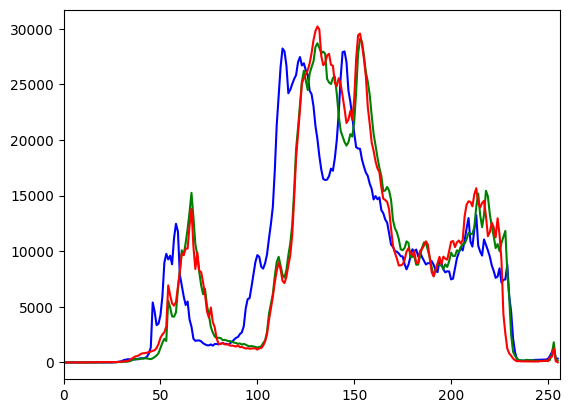

In [4]:
img = cv2.imread('./assets/1.jpg')
color = ('b', 'g', 'r')
for i, col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color = col)
    plt.xlim([0, 256])

### mask 操作

(1706, 1279, 3)


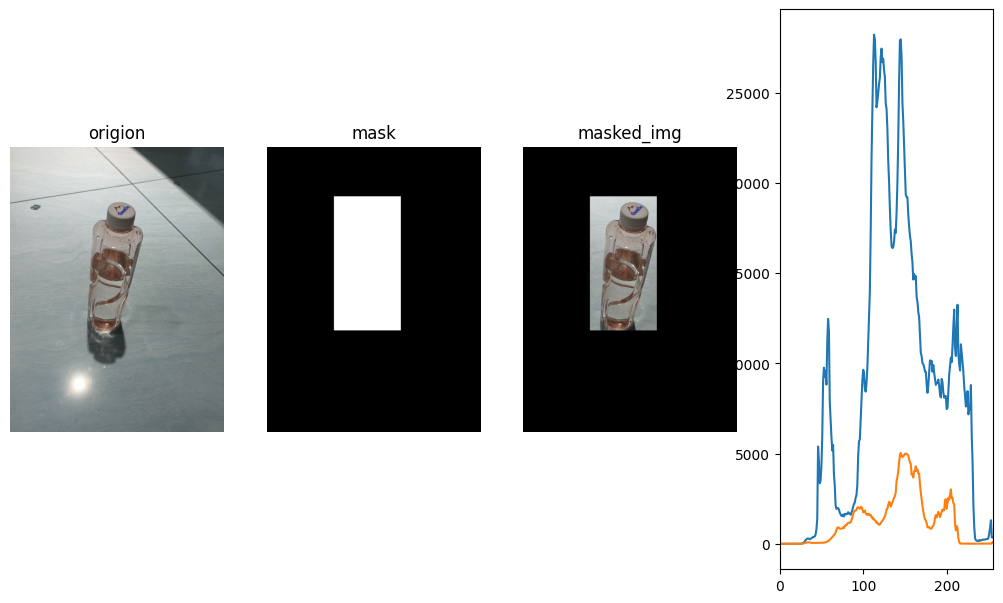

In [21]:
img = cv2.imread('./assets/1.jpg')
print(img.shape)
# 创建 mask
mask = np.zeros(img.shape[:2], np.uint8)
mask[300:1100, 400:800] = 255

masked_img = cv2.bitwise_and(img, img, mask = mask)

hist_full = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_mask = cv2.calcHist([img], [0], mask, [256], [0, 256])

plt.figure(figsize=(16, 16))
plt.subplot(251), plt.imshow(img, 'gray'), plt.title("origion"), plt.axis('off')
plt.subplot(252), plt.imshow(mask, 'gray'), plt.title("mask"), plt.axis('off')
plt.subplot(253), plt.imshow(masked_img, 'gray'), plt.title("masked_img"), plt.axis('off')
plt.subplot(254), plt.plot(hist_full), plt.plot(hist_mask), plt.xlim([0, 256])
plt.show()

### 直方图均衡化

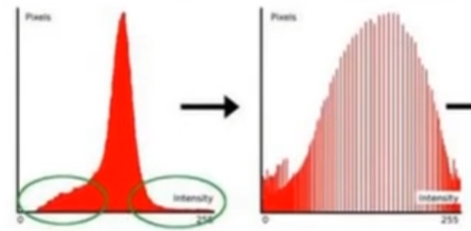

(<Axes: >,
 (0.0, 256.0),
 (0.0, 256.0, -1489.3000000000002, 31275.3))

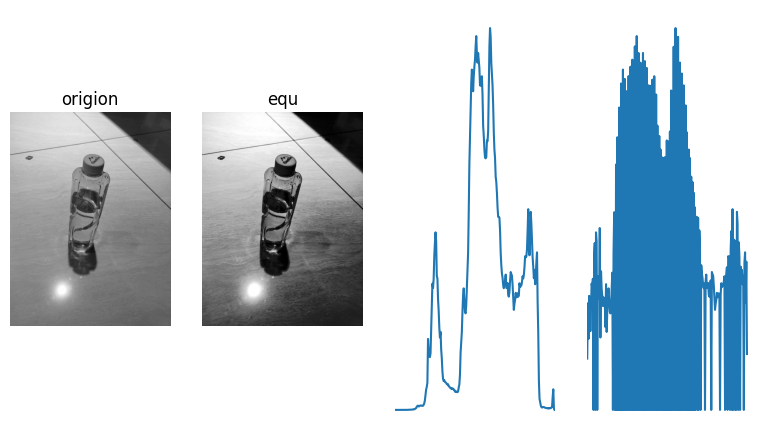

In [30]:
img = cv2.imread('./assets/1.jpg', 0)

# 均衡化
equ = cv2.equalizeHist(img)

hist_img = cv2.calcHist([img], [0], None, [256], [0, 256])
hist_equ = cv2.calcHist([equ], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 12))
plt.subplot(251), plt.imshow(img, 'gray'), plt.title("origion"), plt.axis('off')
plt.subplot(252), plt.imshow(equ, 'gray'), plt.title("equ"), plt.axis('off')

plt.subplot(253), plt.plot(hist_img), plt.xlim([0, 256]), plt.axis('off')
plt.subplot(254), plt.plot(hist_equ), plt.xlim([0, 256]), plt.axis('off')

### 自适应直方图均衡化

(<Axes: title={'center': 'res'}>,
 Text(0.5, 1.0, 'res'),
 (-0.5, 3836.5, 1705.5, -0.5))

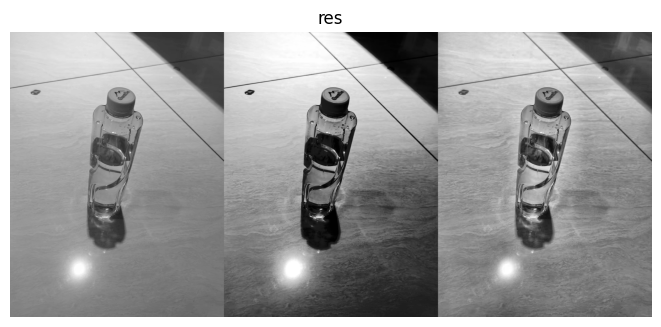

In [37]:
img = cv2.imread('./assets/1.jpg', 0)
equ = cv2.equalizeHist(img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

res_clahe = clahe.apply(img)
res = np.hstack((img, equ, res_clahe))

plt.figure(figsize=(48, 48))
plt.subplot(251), plt.imshow(res, 'gray'), plt.title("res"), plt.axis('off')